# Transport Equation (1-dim)

### Given by (if c > 0):

$$
u_{t} + cu_{x} = 0 \\
u(x,0) = f(x) \\
u(0,t) = g(t)
$$

$
\begin{aligned}
&\text{We use finite difference to expand } u_{t} \text{ and } u_{x} \\
&u_{t} = \frac{u^{n+1}_{j} - u^{n}_{j}}{\Delta t} \\
&u_{x} = \frac{u^{n}_{j} - u^{n}_{j-1}}{\Delta x} \\
&\text{We solve for the (n+1)th time step and this is how we will update our solution matrix} \\
&u^{n+1}_{j} = \lambda(u^{n}_{j} - u^{n}_{j-1}) + u^{n}_{j} \\
&\text{where } \lambda = c\frac{\Delta t}{\Delta x} \text{ and } 0 \leq \lambda \leq 1 \text{ to ensure stability of solution}
\end{aligned}
$



In [1]:
from utils import *

In [5]:
def transport_solver(x, t, c, f, g):
    '''
    x: space domain
    t: time domain
    c: transport constant
    f: initial condition 
    g: left boundary condition
    '''
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    lam = c*dt/dx
    assert(0 <= lam <= 1), 'Choose different step sizes for space and time'
    
    u = np.zeros((len(t), len(x)))
    u[0, ] = f
    #J = len(x) - 1
    for n in range(len(t) - 1):        
        #for vectorized operation
        #u[n+1, 1:J+1] = lam*(u[n, 1:J+1] - u[n, 0:J]) + u[n,1:J+1]
        
        for j in range(1, len(x)):
            u[n+1,j] = -lam*(u[n,j] - u[n, j-1]) + u[n,j]
        u[n+1, 0] = g[n+1]
    
    return u

In [6]:
x = np.linspace(0, 10, 101)  # 101 points from 0 to 10
t = np.linspace(0, 2, 101)   # 101 points from 0 to 2
c = 2.0  # transport velocity

# Initial condition: Gaussian pulse
x0 = 2.0  # initial center of pulse
sigma = 0.5  # width of pulse
f = np.exp(-((x - x0)**2) / (2*sigma**2))
g = np.zeros(len(t))

u = transport_solver(x, t, c, f, g)

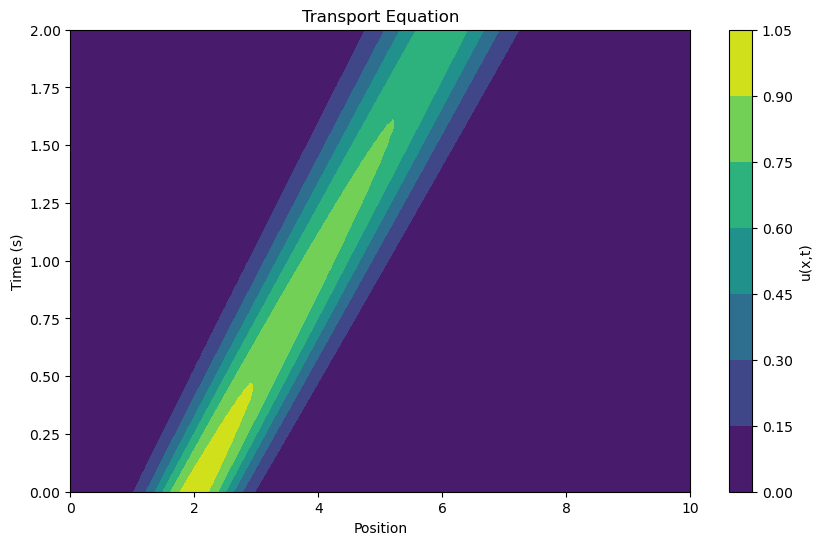

In [7]:
transport_plot(x, t, u) 

In [8]:
ani = transport_animated_plot(x, t, u)
HTML(ani.to_jshtml())